# Assignment No. 2

Name: yash vyas<br>
Roll No.: IT-2K24-97

## Question 3: Numerical Differentiation

### Method 3.1: Differentiation Based on Interpolation

**Assumptions**

- x_points are distinct.
- y_points are known at each x_points value.
- x is within the interpolation range.

**Algorithm (Differentiation Based on Interpolation)**

1. Start
2. Read x_points, y_points, and x
3. For each i, compute derivative of Lagrange basis at x
4. Sum y_points[i] * basis_derivative to get derivative
5. Print derivative
6. Stop
7. End

Approximate derivative: 4.0


,i,x_i,y_i,L_i'(x),y_i * L_i'(x)
0,0,1.0,1.0,-0.5,-0.5
1,1,2.0,4.0,0.0,0.0
2,2,3.0,9.0,0.5,4.5


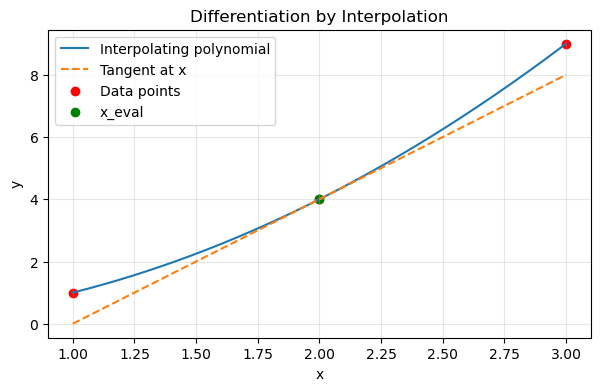

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def differentiation_by_interpolation(x_points, y_points, x):
    n = len(x_points)
    if n != len(y_points):
        raise ValueError("x_points and y_points must have the same length.")

    derivative = 0.0
    basis_rows = []
    for i in range(n):
        basis_derivative = 0.0
        for j in range(n):
            if j == i:
                continue
            term = 1.0 / (x_points[i] - x_points[j])
            for k in range(n):
                if k != i and k != j:
                    term *= (x - x_points[k]) / (x_points[i] - x_points[k])
            basis_derivative += term
        derivative += y_points[i] * basis_derivative
        basis_rows.append({
            "i": i,
            "x_i": x_points[i],
            "y_i": y_points[i],
            "L_i'(x)": basis_derivative,
            "y_i * L_i'(x)": y_points[i] * basis_derivative,
        })
    return derivative, pd.DataFrame(basis_rows)


def lagrange_interpolation(x_points, y_points, x):
    n = len(x_points)
    result = 0.0
    for i in range(n):
        term = y_points[i]
        for j in range(n):
            if i != j:
                term *= (x - x_points[j]) / (x_points[i] - x_points[j])
        result += term
    return result


x_pts = [1.0, 2.0, 3.0]
y_pts = [1.0, 4.0, 9.0]
x_eval = 2.0
deriv, table = differentiation_by_interpolation(x_pts, y_pts, x_eval)
print("Approximate derivative:", deriv)
display(table)

xs = np.linspace(min(x_pts), max(x_pts), 200)
ys = [lagrange_interpolation(x_pts, y_pts, x) for x in xs]
tangent = [lagrange_interpolation(x_pts, y_pts, x_eval) + deriv * (x - x_eval) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="Interpolating polynomial")
plt.plot(xs, tangent, "--", label="Tangent at x")
plt.scatter(x_pts, y_pts, color="red", label="Data points")
plt.scatter([x_eval], [lagrange_interpolation(x_pts, y_pts, x_eval)], color="green", label="x_eval")
plt.title("Differentiation by Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n^3)

Space Complexity: O(1)

### Method 3.2: Differentiation Based on Finite Differences

**Assumptions**

- f(x) is differentiable near x.
- Step size h > 0 is small.

**Algorithm (Finite Difference Differentiation)**

1. Start
2. Read function f(x), point x, step size h
3. Compute forward difference: (f(x+h) - f(x)) / h
4. Compute backward difference: (f(x) - f(x-h)) / h
5. Compute central difference: (f(x+h) - f(x-h)) / (2h)
6. Print approximations
7. Stop
8. End

,Method,Approx,Error
0,Forward,12.0006,6.000100e-04
1,Backward,11.9994,5.999900e-04
2,Central,12.0000,1.000845e-08
3,Exact,12.0000,0.000000e+00


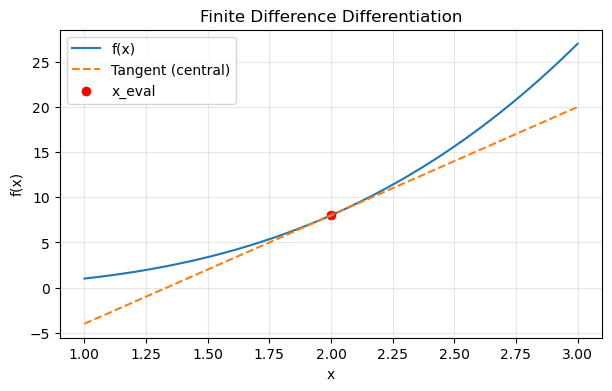

Forward difference: 12.000600010022566
Backward difference: 11.999400009994332
Central difference: 12.00000001000845


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def finite_difference_derivatives(func, x, h=1e-5):
    forward = (func(x + h) - func(x)) / h
    backward = (func(x) - func(x - h)) / h
    central = (func(x + h) - func(x - h)) / (2 * h)
    return forward, backward, central


def f_diff(x):
    return x**3


x_eval = 2.0
h = 1e-4
fwd, bwd, ctr = finite_difference_derivatives(f_diff, x_eval, h=h)
exact = 3 * x_eval**2

rows = [
    {"Method": "Forward", "Approx": fwd, "Error": abs(fwd - exact)},
    {"Method": "Backward", "Approx": bwd, "Error": abs(bwd - exact)},
    {"Method": "Central", "Approx": ctr, "Error": abs(ctr - exact)},
    {"Method": "Exact", "Approx": exact, "Error": 0.0},
]
table = pd.DataFrame(rows)
display(table)

xs = np.linspace(x_eval - 1.0, x_eval + 1.0, 200)
ys = [f_diff(x) for x in xs]
tangent = [f_diff(x_eval) + ctr * (x - x_eval) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.plot(xs, tangent, "--", label="Tangent (central)")
plt.scatter([x_eval], [f_diff(x_eval)], color="red", label="x_eval")
plt.title("Finite Difference Differentiation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Forward difference:", fwd)
print("Backward difference:", bwd)
print("Central difference:", ctr)

Time Complexity: O(1)

Space Complexity: O(1)